# The paper's figures

The two figures in [arXiv:1904.12391](https://arxiv.org/abs/1904.12391), reproduced here. They were previously drawn by two plotting modules that this notebook replaces: three-flavor and two-flavor probabilities against energy at the DUNE baseline, for four scenarios at once.

In [1]:
import sys
import os

# Works whether or not the package is installed: these notebooks sit one
# level below the repository root, so src/ is one directory up.
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import matplotlib.pyplot as plt

import globaldefs as gd
import oscprob2nu
import oscprob3nu
import oscprob4nu
import hamiltonians2nu
import hamiltonians3nu
import hamiltonians4nu

%matplotlib inline
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 90,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 11, 'legend.frameon': False,
                     # Axes end exactly at the data: no padding beyond
                     # x_min/x_max or y_min/y_max.
                     'axes.xmargin': 0.0, 'axes.ymargin': 0.0})

# The three-flavor vacuum Hamiltonian at the NuFit best fit, normal ordering.
# It is energy-independent; dividing by the energy is what the builders do.
H_VAC_3NU = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
    gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, gd.DCP_NO_BF,
    gd.D21_NO_BF, gd.D31_NO_BF)

KM = gd.CONV_KM_TO_INV_EV      # multiply a length in km to get eV^-1
GEV = 1.0e9                    # multiply an energy in GeV to get eV

## Three flavors

Vacuum, constant-density matter, matter with non-standard interactions, and a CPT-odd Lorentz invariance-violating background, at $L = 1300$ km. All four use the default parameters in `globaldefs`, so the figure is reproducible from the repository alone.

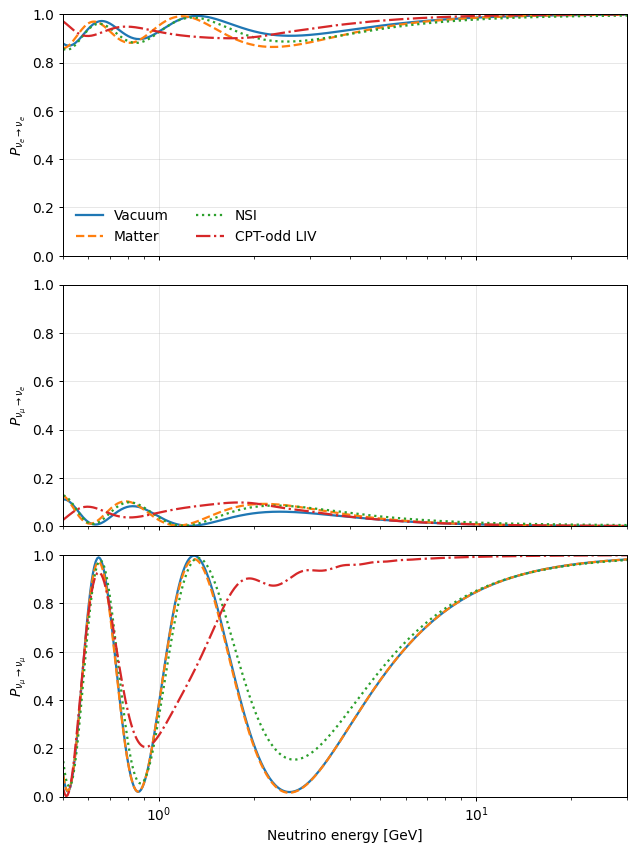

In [2]:
L = 1300.0*KM
E_gev = np.logspace(np.log10(0.5), np.log10(30.0), 400)
E = E_gev*GEV

p = {
    "Vacuum": oscprob3nu.probabilities_3nu(
        np.asarray(H_VAC_3NU)/E[:, None, None], L),
    "Matter": oscprob3nu.probabilities_3nu(
        hamiltonians3nu.hamiltonian_3nu_matter(
            H_VAC_3NU, E, gd.VCC_EARTH_CRUST), L),
    "NSI": oscprob3nu.probabilities_3nu(
        hamiltonians3nu.hamiltonian_3nu_nsi(
            H_VAC_3NU, E, gd.VCC_EARTH_CRUST, gd.EPS_3), L),
    "CPT-odd LIV": oscprob3nu.probabilities_3nu(
        hamiltonians3nu.hamiltonian_3nu_liv(
            H_VAC_3NU, E, gd.SXI12, gd.SXI23, gd.SXI13,
            gd.DXICP, gd.B1, gd.B2, gd.B3, gd.LAMBDA), L),
}

styles = ["-", "--", ":", "-."]
panels = [(0, r"$P_{\nu_e \to \nu_e}$"),
          (3, r"$P_{\nu_\mu \to \nu_e}$"),
          (4, r"$P_{\nu_\mu \to \nu_\mu}$")]

fig, axes = plt.subplots(3, 1, figsize=(7.2, 9.6), sharex=True)
for ax, (k, ylabel) in zip(axes, panels):
    for (name, prob), ls in zip(p.items(), styles):
        ax.semilogx(E_gev, prob[:, k], ls, lw=1.8, label=name)
    ax.set_ylabel(ylabel)
    ax.set_xlim(E_gev[0], E_gev[-1])
    ax.set_ylim(0.0, 1.0)
axes[0].legend(loc="lower left", ncol=2)
axes[-1].set_xlabel("Neutrino energy [GeV]")
fig.tight_layout()
plt.show()

## Two flavors

The same four scenarios in the two-flavor system, driven by $\Delta m^2_{31}$ and $\theta_{23}$, over a slightly wider energy range.

Note the first argument: the builders take $\sin\theta$, not $\theta$.

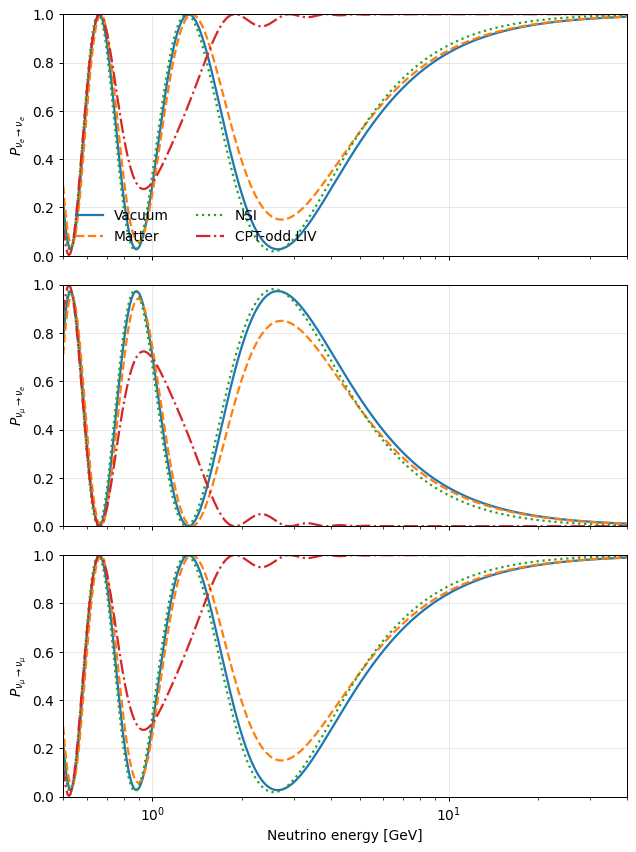

In [3]:
E_gev = np.logspace(np.log10(0.5), np.log10(40.0), 400)
E = E_gev*GEV

H2_VAC = hamiltonians2nu.hamiltonian_2nu_vacuum_energy_independent(
    gd.S23_NO_BF, gd.D31_NO_BF)

p2 = {
    "Vacuum": oscprob2nu.probabilities_2nu(
        np.asarray(H2_VAC)/E[:, None, None], L),
    "Matter": oscprob2nu.probabilities_2nu(
        hamiltonians2nu.hamiltonian_2nu_matter(
            H2_VAC, E, gd.VCC_EARTH_CRUST), L),
    "NSI": oscprob2nu.probabilities_2nu(
        hamiltonians2nu.hamiltonian_2nu_nsi(
            H2_VAC, E, gd.VCC_EARTH_CRUST, gd.EPS_2), L),
    "CPT-odd LIV": oscprob2nu.probabilities_2nu(
        hamiltonians2nu.hamiltonian_2nu_liv(
            H2_VAC, E, gd.SXI12, gd.B1, gd.B3, gd.LAMBDA), L),
}

panels2 = [(0, r"$P_{\nu_e \to \nu_e}$"),
           (2, r"$P_{\nu_\mu \to \nu_e}$"),
           (3, r"$P_{\nu_\mu \to \nu_\mu}$")]

fig, axes = plt.subplots(3, 1, figsize=(7.2, 9.6), sharex=True)
for ax, (k, ylabel) in zip(axes, panels2):
    for (name, prob), ls in zip(p2.items(), styles):
        ax.semilogx(E_gev, prob[:, k], ls, lw=1.8, label=name)
    ax.set_ylabel(ylabel)
    ax.set_xlim(E_gev[0], E_gev[-1])
    ax.set_ylim(0.0, 1.0)
axes[0].legend(loc="lower left", ncol=2)
axes[-1].set_xlabel("Neutrino energy [GeV]")
fig.tight_layout()
plt.show()

---

**Previous:** [Performance](09_performance.ipynb)  
**Next:** [Exact versus the approximations](11_exact_vs_approximations.ipynb) --- where the familiar formulas break, and by how much  
[API reference](https://mbustama.github.io/NuOscProbExact/functions.html) &middot; [Numerical recipes](https://mbustama.github.io/NuOscProbExact/recipes.html) &middot; [All notebooks](.)